# BÀI TOÁN HỒI QUY TUYẾN TÍNH BỘI CHO DỮ LIỆU DẠNG HỖN HỢP

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
from sklearn.model_selection import train_test_split

from scipy.stats import t
from scipy.stats import norm

from IPython.display import display, Latex

# Đọc dữ liệu

In [90]:
# Đọc dữ liệu
df_raw = pd.read_csv("D:/Mo_Hinh_TK_Tuyen_Tinh/DATA/insurance.csv")
df_raw

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [91]:
# Tóm tắt thông tin
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [92]:
display(Latex(r"$\textbf{Tuổi (age)}: \text{tuổi của người được bảo hiểm (Dữ liệu số)}$"))
display(Latex(r"$\textbf{Giới tính (sex)}: \text{giới tính của người được bảo hiểm (Dữ liệu phận loại: Nam, nữ)}$"))
display(Latex(r"$\textbf{Body mass index (bmi)}: \text{chỉ số bmi của người được bảo hiểm (Dữ liệu số)}$"))
display(Latex(r"$\textbf{Số con (children)}: \text{số con của người được bảo hiểm (Dữ liệu số)}$"))
display(Latex(r"$\textbf{Hút thuốc (smoker)}: \text{cho biết người được bảo hiểm có hút thuốc hay không (Dữ liệu phân loại: Có, Không)}$"))
display(Latex(r"$\textbf{Khu vực (region)}: \text{khu vực sinh sống của người được bảo hiểm (Dữ liệu phân loại: Đông Bắc, Tây Bắc, Đông Nam , Tây Nam)}$"))
display(Latex(r"$\textbf{Chi phí bảo hiểm (charges)}: \text{chi phí y tế mà công ty bảo hiểm chi trả cho người được bảo hiểm (Dữ liệu số)}$"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# Trực quan hóa dữ liệu

Text(0.5, 1.0, 'Ma trận hệ số tương quan')

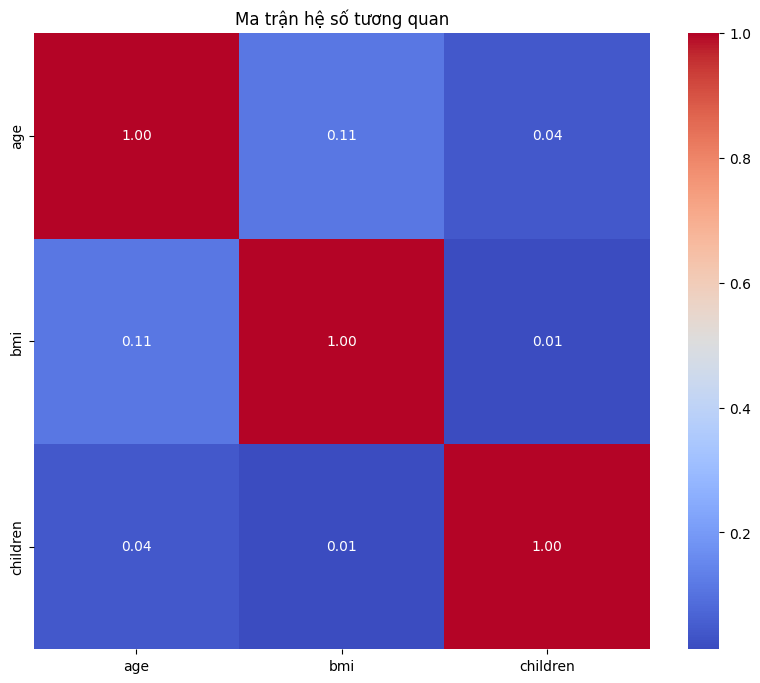

In [93]:
# tính ma trận hệ số tương quan cho các biến định lượng
plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[['age', 'bmi', 'children']].corr(),
            annot=True,         # hiển thị giá trị
            fmt=".2f",          # 2 chữ số thập phân
            cmap="coolwarm",    # thang màu
            square=True)

plt.title("Ma trận hệ số tương quan")

<Axes: >

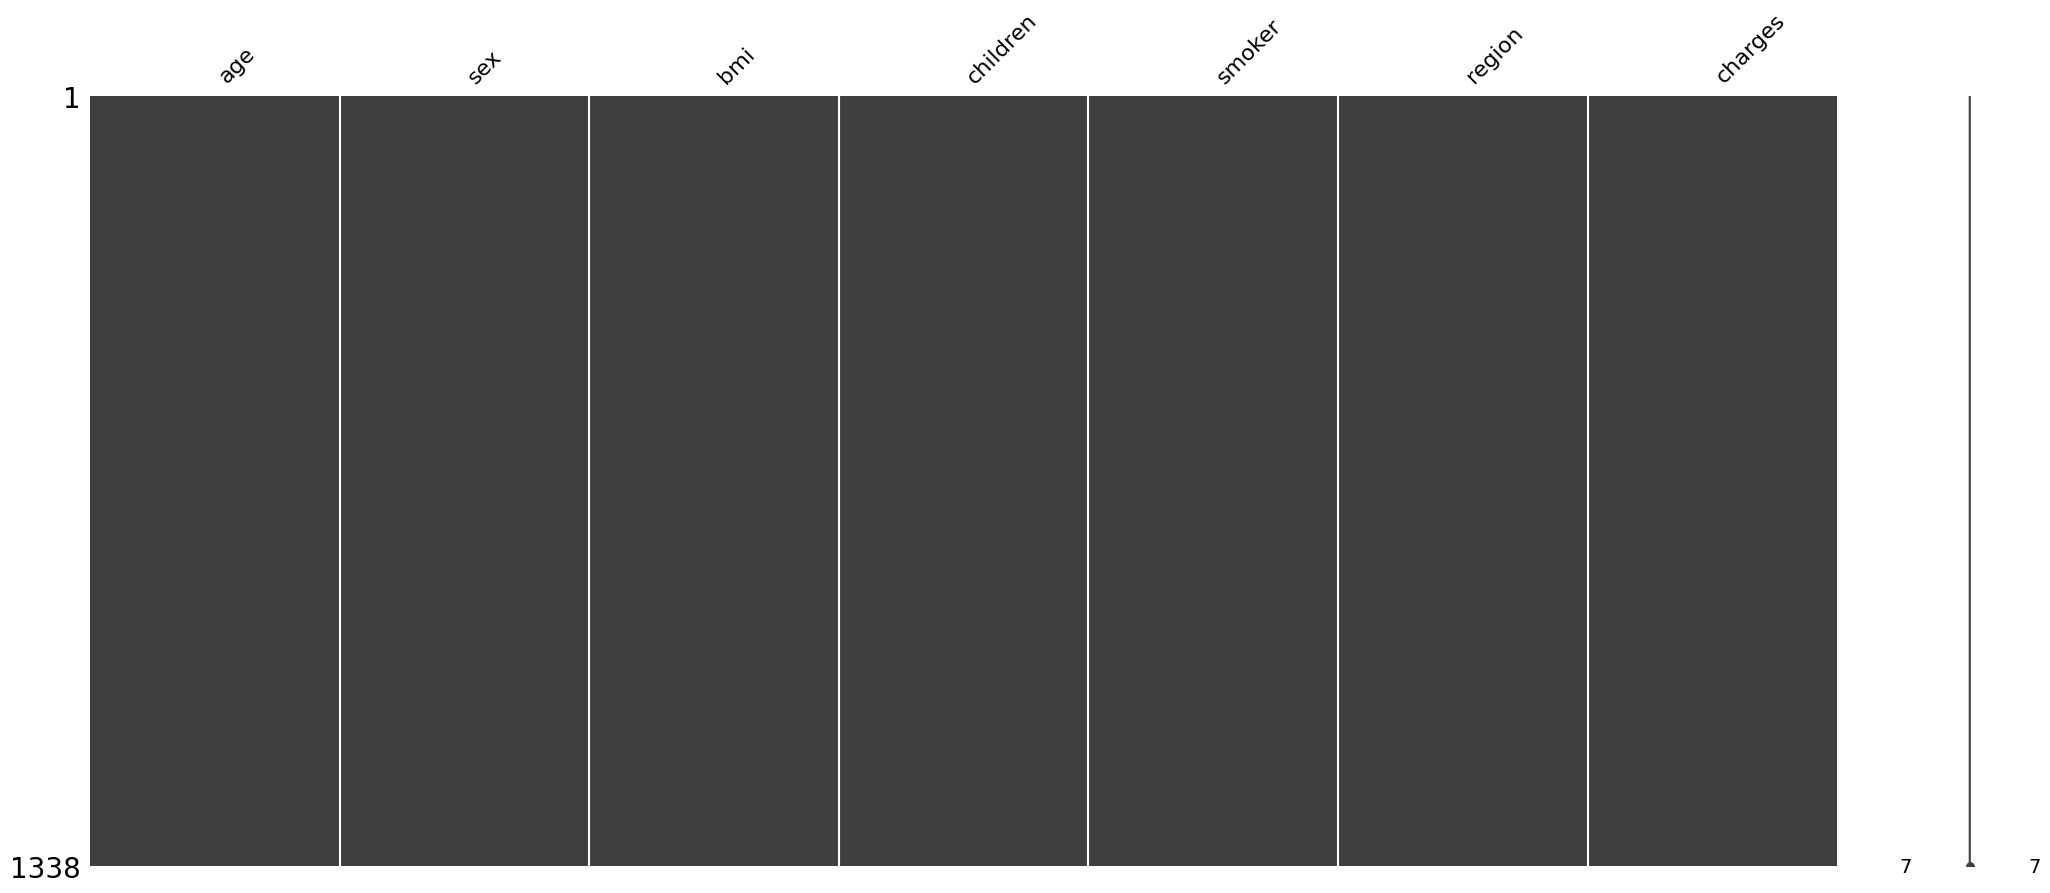

In [94]:
msno.matrix(df_raw)

<Axes: >

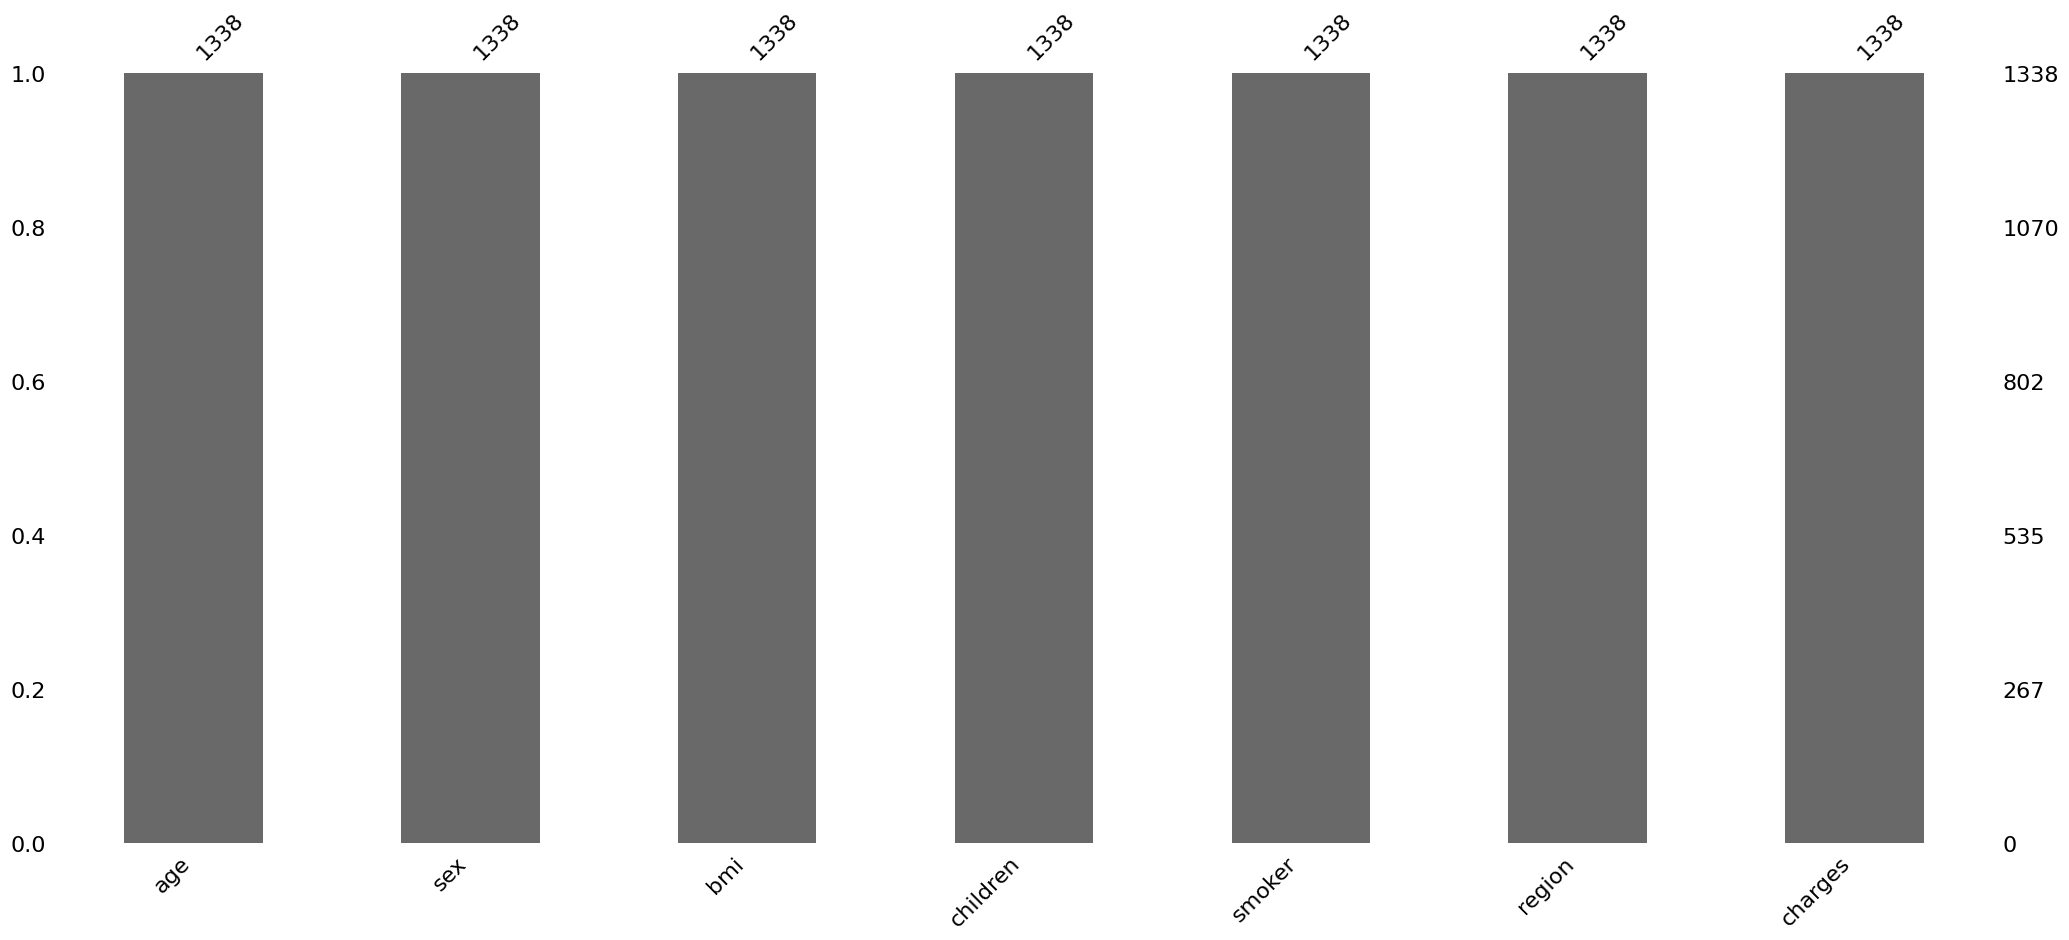

In [95]:
msno.bar(df_raw)

In [96]:
# tính tổng dữ liệu khuyết của các biến
df_raw.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: >

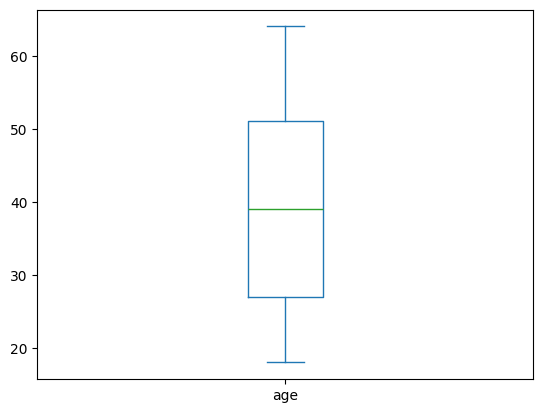

In [97]:
df_raw['age'].plot(kind='box')

<Axes: >

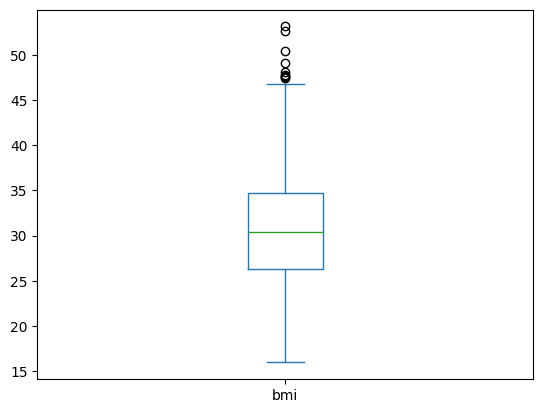

In [98]:
df_raw['bmi'].plot(kind='box')

<Axes: >

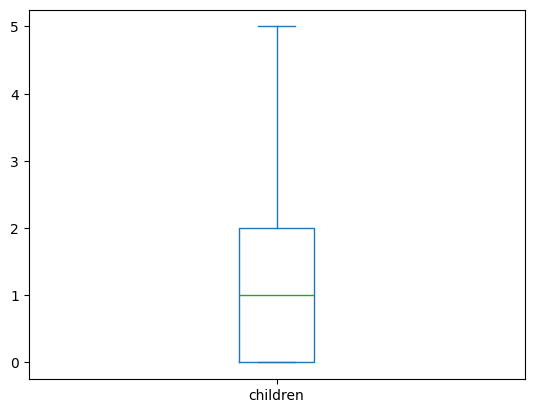

In [99]:
df_raw['children'].plot(kind='box')

# Thống kê mô tả

In [100]:
# tính vector trung bình cho các biến định lượng
df_raw[['age', 'bmi', 'children']].mean(axis=0)

age         39.207025
bmi         30.663397
children     1.094918
dtype: float64

In [101]:
# tính ma trận phương sai - hiệp phương sai
df_raw[['age', 'bmi', 'children']].cov()

,age,bmi,children
age,197.401387,9.362337,0.719303
bmi,9.362337,37.187884,0.093795
children,0.719303,0.093795,1.453213


# Mã hóa các biến định tính

In [102]:
# tóm tắt mức (level) của biến định tính giới tính (sex)
df_raw['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [103]:
# mã hóa (encoding) biến giới tính (sex)
gender_list = []            # tạo 1 list rỗng
for item in df_raw['sex']:  
    if (item == 'male'):
        value = 1
    else:
        value = 0
    gender_list += [value]  # nối 2 list

In [104]:
# thêm cột biến giả tên gender vào data frame
df_raw['gender'] = pd.Series(gender_list) # chuyển từ dạng list sang dạng series

In [105]:
# tóm tắt level của biến smoker
df_raw['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [106]:
# mã hóa (encoding) biến định tính smoker
is_smoker_list = []             # tạo 1 list rỗng
for item in df_raw['smoker']:
    if (item == 'yes'):
        value = 1
    else:
        value = 0
    is_smoker_list += [value]   # nối chuỗi

In [107]:
# thêm biến giả (is_smoker) vào data frame
df_raw['is_smoker'] = pd.Series(is_smoker_list) # chuyển dạng list sang dạng series

In [108]:
# tóm tắt level của biến định tính region
df_raw['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [109]:
# mã hóa (encoding) cho level southwest 
region_southwest_list = []              # tạo 1 list rỗng
for item in df_raw['region']:
    if (item == 'southwest'):
        value = 1
    else:
        value = 0
    region_southwest_list += [value]    # nối list

In [110]:
# thêm cột region_southwest vào data frame
df_raw['region_southwest'] = pd.Series(region_southwest_list) # chuyển từ list sang series

In [111]:
# mã hóa (encoding) cho level northwest
region_northwest_list = []              # tạo list rỗng
for item in df_raw['region']:
    if (item == 'northwest'):
        value = 1
    else:
        value = 0
    region_northwest_list += [value]    # nối list

In [112]:
# thêm cột region_northwest vào data frame
df_raw['region_northwest'] = pd.Series(region_northwest_list) # chuyển từ list sang series

In [113]:
# mã hóa (encoding) cho level northeast
region_northeast_list = []              # tạo list rỗng
for item in df_raw['region']:
    if (item == 'northeast'):
        value = 1
    else:
        value = 0
    region_northeast_list += [value]    # nối list

In [114]:
# thêm cột region_northeast vào data frame
df_raw['region_northeast'] = pd.Series(region_northeast_list) # chuyển từ list sang series

In [115]:
# bỏ các biến đã mã hóa
df_raw.drop(columns=['sex', 'smoker', 'region'], inplace=True)

In [116]:
df_raw

,age,bmi,children,charges,gender,is_smoker,region_southwest,region_northwest,region_northeast
0,19,27.900,0,16884.92400,0,1,1,0,0
1,18,33.770,1,1725.55230,1,0,0,0,0
2,28,33.000,3,4449.46200,1,0,0,0,0
3,33,22.705,0,21984.47061,1,0,0,1,0
4,32,28.880,0,3866.85520,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,0,1,0
1334,18,31.920,0,2205.98080,0,0,0,0,1
1335,18,36.850,0,1629.83350,0,0,0,0,0
1336,21,25.800,0,2007.94500,0,0,1,0,0


In [117]:
# dữ liệu đã được làm sạch
df_cleaned = df_raw
df_cleaned

,age,bmi,children,charges,gender,is_smoker,region_southwest,region_northwest,region_northeast
0,19,27.900,0,16884.92400,0,1,1,0,0
1,18,33.770,1,1725.55230,1,0,0,0,0
2,28,33.000,3,4449.46200,1,0,0,0,0
3,33,22.705,0,21984.47061,1,0,0,1,0
4,32,28.880,0,3866.85520,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,0,1,0
1334,18,31.920,0,2205.98080,0,0,0,0,1
1335,18,36.850,0,1629.83350,0,0,0,0,0
1336,21,25.800,0,2007.94500,0,0,1,0,0


# Lý thuyết toán 

In [118]:
display(Latex(r""" 
\begin{equation*}
    \begin{matrix}
    Y & X_1 & X_2 & \ldots & X_p \\
    y_1 & x_{1,1} & x_{1,2} & \ldots & x_{1, p} \\
    y_2 & x_{2,1} & x_{2,2} & \ldots & x_{2, p} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    y_n & x_{n,1} & x_{n,2} & \ldots & x_{n, p} \\
\end{matrix}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [119]:
display(Latex(r""" 
\begin{array}{cccc}
\mathbf{y} =
\begin{bmatrix}
        y_1 \\
        y_2 \\
        \vdots \\
        y_n
    \end{bmatrix}_{n \times 1}
&
\mathbb{X} =
\begin{bmatrix}
        1 & x_{1, 1} & x_{1, 2} & \ldots & x_{1, p} \\
        1 & x_{2, 1} & x_{2, 2} & \ldots & x_{2, p} \\
        \vdots & \vdots & \vdots & \ddots & \vdots \\
        1 & x_{n, 1} & x_{n, 2} & \ldots & x_{n, p} \\
    \end{bmatrix}_{n \times (p + 1)}
&
\boldsymbol{\beta} =
\begin{bmatrix}
        \beta_0 \\
        \beta_1 \\
        \vdots \\
        \beta_p
    \end{bmatrix}_{(p + 1) \times 1}
&
\boldsymbol{\Psi} =
\begin{bmatrix}
        \psi_1 \\
        \psi_2 \\
        \vdots \\
        \psi_n
    \end{bmatrix}_{n \times 1}
\end{array}
"""))

<IPython.core.display.Latex object>

In [120]:
display(Latex(r""" 
\begin{equation*}
    \textbf{y} = \mathbb{X} \boldsymbol{\beta} + \boldsymbol{\Psi}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [121]:
display(Latex(r""" 
\begin{equation*}
    \begin{cases}
        y_1 = \beta_0 + \beta_1 x_{1, 1} + \beta_2 x_{1, 2} + \ldots + \beta_p x_{1, p}  + \psi_1 \\
        y_2 = \beta_0 + \beta_1 x_{2, 1} + \beta_2 x_{2, 2} + \ldots + \beta_p x_{2, p}  + \psi_2 \\
        \hspace{3.5cm} \vdots \\
        y_n = \beta_0 + \beta_1 x_{n, 1} + \beta_2 x_{n, 2} + \ldots + \beta_p x_{n, p}  + \psi_n \\
    \end{cases}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [122]:
df1 = df_cleaned.copy()

# Tạo ma trận X

In [123]:
df1['one_dummy'] = pd.Series(1, range(0, 1338))

In [124]:
df1.columns

Index(['age', 'bmi', 'children', 'charges', 'gender', 'is_smoker',
       'region_southwest', 'region_northwest', 'region_northeast',
       'one_dummy'],
      dtype='object')

In [125]:
# tạo ma trận thiết kế
df1 = df1[['one_dummy', 'age', 'bmi', 'children', 'charges', 'gender', 'is_smoker', 'region_southwest', 'region_northwest', 'region_northeast']]
df1

,one_dummy,age,bmi,children,charges,gender,is_smoker,region_southwest,region_northwest,region_northeast
0,1,19,27.900,0,16884.92400,0,1,1,0,0
1,1,18,33.770,1,1725.55230,1,0,0,0,0
2,1,28,33.000,3,4449.46200,1,0,0,0,0
3,1,33,22.705,0,21984.47061,1,0,0,1,0
4,1,32,28.880,0,3866.85520,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,1,50,30.970,3,10600.54830,1,0,0,1,0
1334,1,18,31.920,0,2205.98080,0,0,0,0,1
1335,1,18,36.850,0,1629.83350,0,0,0,0,0
1336,1,21,25.800,0,2007.94500,0,0,1,0,0


# Chia dataset thành tập train và tập test

In [126]:
# chia dữ liệu thành 2 phần (train - test) với tỷ lệ 80 - 20
X = df1.drop(columns=['charges']) # ma trận X bỏ cột charges 
y = df1['charges']                # vector y chỉ có cột charges

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42     # để tái lập kết quả
)

In [127]:
X_train

,one_dummy,age,bmi,children,gender,is_smoker,region_southwest,region_northwest,region_northeast
560,1,46,19.950,2,0,0,0,1,0
1285,1,47,24.320,0,0,0,0,0,1
1142,1,52,24.860,0,0,0,0,0,0
969,1,39,34.320,5,0,0,0,0,0
486,1,54,21.470,3,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1095,1,18,31.350,4,0,0,0,0,1
1130,1,39,23.870,5,0,0,0,0,0
1294,1,58,25.175,0,1,0,0,0,1
860,1,37,47.600,2,0,1,1,0,0


In [128]:
y_train

560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
           ...     
1095     4561.18850
1130     8582.30230
1294    11931.12525
860     46113.51100
1126    10214.63600
Name: charges, Length: 1070, dtype: float64

In [129]:
X_test

,one_dummy,age,bmi,children,gender,is_smoker,region_southwest,region_northwest,region_northeast
764,1,45,25.175,2,0,0,0,0,1
887,1,36,30.020,0,0,0,0,1,0
890,1,64,26.885,0,0,1,0,1,0
1293,1,46,25.745,3,1,0,0,1,0
259,1,19,31.920,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...
109,1,63,35.090,0,1,1,0,0,0
575,1,58,27.170,0,0,0,0,1,0
535,1,38,28.025,1,1,0,0,0,1
543,1,54,47.410,0,0,1,0,0,0


In [130]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

# Tính các ước lượng cho hệ số hồi quy (estimated coefficients)

In [131]:
display(Latex(r"""
\begin{equation*}
    \boldsymbol{\widehat{\beta}} = (\mathbb{X}^T \mathbb{X} )^{-1} \mathbb{X}^T \textbf{y}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [132]:
def estimate_coefficients(matrix_train, vector_train):
    vector_estimate_coef = np.linalg.pinv((matrix_train.T) @ matrix_train) @ (matrix_train.T) @ vector_train
    return vector_estimate_coef

In [133]:
estimate_coefficients(X_train, y_train)

0   -12589.083347
1      256.975706
2      337.092552
3      425.278784
4      -18.591692
5    23651.128856
6     -151.935058
7      287.186970
8      657.864297
dtype: float64

In [134]:
i = 0
for item in list(estimate_coefficients(X_train, y_train)):
    print(f'beta_{i}: {item:0.4f}')
    i += 1

beta_0: -12589.0833
beta_1: 256.9757
beta_2: 337.0926
beta_3: 425.2788
beta_4: -18.5917
beta_5: 23651.1289
beta_6: -151.9351
beta_7: 287.1870
beta_8: 657.8643


In [135]:
display(Latex(r""" 
\begin{align*}
    \text{charges} 
    &= \widehat{\beta_0} + \widehat{\beta_1} age + \widehat{\beta_2} bmi + \widehat{\beta_3} children
    + \widehat{\beta_4} gender + \widehat{\beta_5} is\_smoker + \widehat{\beta_6} region\_southwest 
    + \widehat{\beta_7} region\_northwest + \widehat{\beta_8} region\_northeast \\
    &= (-12589.0833) + (256.9757) age + (337.0926) bmi + (425.2788) children + (-18.5917) gender + (23651.1289) is\_smoker \\
    &+ (-151.9351) region\_southwest + (287.1870) region\_northwest + (657.8643) region\_northeast
\end{align*}
"""))

<IPython.core.display.Latex object>

# Tính ước lượng phương sai cho sai số 

In [136]:
display(Latex(r""" 
\begin{equation*}
    \boldsymbol{\widehat{\sigma^2}} = \frac{SSE}{n - (p + 1)} 
    = \frac{\Big(\textbf{y} - \mathbb{X} \boldsymbol{\widehat{\beta}}\Big)^T \Big(\textbf{y} - \mathbb{X} \boldsymbol{\widehat{\beta}}\Big)}{n - (p + 1)}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [137]:
def estimate_error_var(matrix_train, vector_train, n, p):
    component = vector_train.values - (matrix_train.values @ (estimate_coefficients(matrix_train, vector_train)).values)
    sigma_square_hat = ((component.T) @ component) / (n - (p + 1))
    return sigma_square_hat

In [138]:
print(f'sigma_square_hat: {estimate_error_var(X_train, y_train, 1070, 8):0.4f}')

sigma_square_hat: 37593892.0086


# Tính các thống kê t (student) cho phép kiểm định

In [139]:
display(Latex(r""" 
\begin{equation*}
    t_{\beta_j} = \frac{\widehat{\beta_j}}{\sqrt{\boldsymbol{\widehat{\sigma^2} \Big[ \Big(\mathbb{X}^T \mathbb{X}\Big)^{-1} \Big]_{j, j}}}}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [140]:
def compute_t_statistic(matrix_train, vector_train, n, p):
    vector_beta_hat = estimate_coefficients(matrix_train, vector_train) 
    sigma_square_hat = estimate_error_var(matrix_train, vector_train, n, p)
    
    for index in range(0, (p + 1)): 
        t_statistic = (vector_beta_hat).values[index] / np.sqrt((sigma_square_hat) * (np.linalg.pinv((matrix_train.T) @ matrix_train))[index, index])
        print(f't_beta_{index}: {t_statistic:0.4f}')

In [141]:
compute_t_statistic(X_train, y_train, 1070, 8)

t_beta_0: -10.3334
t_beta_1: 19.0670
t_beta_2: 10.3814
t_beta_3: 2.7499
t_beta_4: -0.0494
t_beta_5: 50.6986
t_beta_6: -0.2859
t_beta_7: 0.5281
t_beta_8: 1.2187


In [142]:
display(Latex(r""" 
\begin{equation*}
    \begin{cases}
        H_0: \beta_j = 0 \\
        H_1: \beta_j \neq 0
    \end{cases}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [143]:
display(Latex(r""" 
\begin{equation*}
    \text{Bác bỏ} \hspace{0.1cm} H_0 \hspace{0.1cm} \text{nếu} \hspace{0.1cm}\Big| t_{\beta_j} \Big| > t^{n - (p + 1)}_{\frac{\alpha}{2}}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [144]:
def hypothesis_testing(matrix_train, vector_train, n, p):
    vector_beta_hat = estimate_coefficients(matrix_train, vector_train)
    sigma_square_hat = estimate_error_var(matrix_train, vector_train, n, p)
    
    t_stat_list = []
    for index in range(0, (p + 1)): 
        t_statistic = (vector_beta_hat).values[index] / np.sqrt((sigma_square_hat) * (np.linalg.pinv((matrix_train.T) @ matrix_train))[index, index])
        t_stat_list += [t_statistic]

    t_quantile = t.ppf(0.975, df = (n - (p + 1)))

    for value in t_stat_list:
        if (np.abs(value) > t_quantile):
            print('Bac bo H_0')
        else:
            print('Chua du co so bac bo H_0')


In [145]:
hypothesis_testing(X_train, y_train, 1070, 8)

Bac bo H_0
Bac bo H_0
Bac bo H_0
Bac bo H_0
Chua du co so bac bo H_0
Bac bo H_0
Chua du co so bac bo H_0
Chua du co so bac bo H_0
Chua du co so bac bo H_0


# Tính hệ số xác định R^2

In [146]:
display(Latex(r""" 
\begin{align*}
    R^2 
    &= \frac{SSR}{SSR + SSE} \\
    &= \frac{\Big( \mathbb{X}_{\text{train}} \boldsymbol{\widehat{\beta}} - \bar{y} \mathbf{1} \Big)^T \Big(\mathbb{X}_{\text{train}} \boldsymbol{\widehat{\beta}} - \bar{y} \mathbf{1} \Big)}
    {\Big( \mathbb{X}_{\text{train}} \boldsymbol{\widehat{\beta}} - \bar{y} \mathbf{1} \Big)^T \Big(\mathbb{X}_{\text{train}} \boldsymbol{\widehat{\beta}} - \bar{y} \mathbf{1} \Big) 
    + \Big(\textbf{y} - \mathbb{X} \boldsymbol{\widehat{\beta}}\Big)^T \Big(\textbf{y} - \mathbb{X} \boldsymbol{\widehat{\beta}}\Big)}
\end{align*}
"""))

<IPython.core.display.Latex object>

In [147]:
def compute_r_square(matrix_train, vector_train, n):
    component = vector_train.values - (matrix_train.values @ (estimate_coefficients(matrix_train, vector_train)).values)

    y_hat = matrix_train @ (estimate_coefficients(matrix_train, vector_train)).values
    y_bar = vector_train.mean()
    vector_y_bar = pd.Series(y_bar, range(0, n))

    ssr = ((y_hat.values - vector_y_bar.values).T) @ (y_hat.values - vector_y_bar.values)
    sse = (component.T) @ component

    r_square = ssr / (ssr + sse)
    return r_square
    

In [148]:
print(f'R^2: {compute_r_square(X_train, y_train, 1070):0.4f}')

R^2: 0.7417


# Tính hệ số R^2 hiệu chỉnh

In [149]:
display(Latex(r""" 
\begin{align*}
    R^2_{adj} 
    &= 1 - \frac{\frac{SSE}{n - (p + 1)}}{\frac{SSR + SSE}{n- 1}}
\end{align*}
"""))

<IPython.core.display.Latex object>

In [150]:
def coumpute_r_square_adj(matrix_train, vector_train, n, p):
    component = vector_train.values - (matrix_train.values @ (estimate_coefficients(matrix_train, vector_train)).values)

    y_hat = matrix_train @ (estimate_coefficients(matrix_train, vector_train)).values
    y_bar = vector_train.mean()
    vector_y_bar = pd.Series(y_bar, range(0, n))

    ssr = ((y_hat.values - vector_y_bar.values).T) @ (y_hat.values - vector_y_bar.values)
    sse = (component.T) @ component

    r_square_adj = 1 - ((sse / (n - (p + 1))) / ((sse + ssr) / (n - 1)))
    return r_square_adj

In [151]:
print(f'R^2_adj: {coumpute_r_square_adj(X_train, y_train, 1070, 8):0.4f}')

R^2_adj: 0.7398


# Tính giá trị dự báo từ đường thẳng hồi quy ước lượng

In [152]:
display(Latex(r""" 
\begin{equation*}
    \widehat{\mathbf{y}} = \mathbb{X}_{\text{test}} \boldsymbol{\widehat{\beta}}
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [153]:
def compute_y_predict(matrix_train, matrix_test, vector_train):
    y_pred = matrix_test @ (estimate_coefficients(matrix_train, vector_train).values)
    return y_pred

In [154]:
compute_y_predict(X_train, X_test, y_train)

764      8969.550274
887      7068.747443
890     36858.410912
1293     9454.678501
259     26973.173457
            ...     
109     39061.500932
575     11761.499198
535      7687.563632
543     40920.291512
846     12318.586653
Length: 268, dtype: float64

# Tính khoảng tin cậy 95% cho giá trị dự báo

In [155]:
display(Latex(r""" 
\begin{equation*}
    \widehat{y_i} - \delta \leq y_i \leq \widehat{y_i} + \delta
\end{equation*}
              
Trong đó:
\begin{equation*}
    \mathbf{x_i}^T = (1; x_{i, 1}, x_{i, 2}, \ldots, x_{i, p})
\end{equation*}  
              
\begin{equation*}
    \delta = t^{n - (p + 1)}_{\frac{\alpha}{2}} \times \sqrt{\boldsymbol{\widehat{\sigma^2}} \Big( 1 + \mathbf{x_i}^T \big( \mathbb{X}^T \mathbb{X} \big)^{-1} \mathbf{x_i} \Big)}
\end{equation*}   
"""))

<IPython.core.display.Latex object>

In [156]:
def compute_lower_bound(matrix_test, matrix_train, vector_train, n_test, n_train, p):
    component_inv = np.linalg.pinv((matrix_train.T) @ matrix_train)
    vector_y_pred = compute_y_predict(matrix_train, matrix_test, vector_train)
    sigma_square_hat = estimate_error_var(matrix_train, vector_train, n_train, p)

    t_quantile = t.ppf(0.975, df = (n_train - (p + 1)))

    lower_bound_list = []
    for i in range(0, n_test):
        lower_bound = vector_y_pred.iloc[i] - (t_quantile * np.sqrt(sigma_square_hat * (1 + (matrix_test.iloc[i].values @ component_inv @ (matrix_test.iloc[i].values).T))))
        
        lower_bound_list += [lower_bound] 
    
    lower_bound_series = pd.Series(lower_bound_list)

    return lower_bound_series


In [157]:
compute_lower_bound(X_test, X_train, y_train, 268, 1070, 8)

0      -3097.846681
1      -4998.301610
2      24745.364542
3      -2622.203028
4      14874.604904
           ...     
263    26960.955078
264     -316.676090
265    -4373.492982
266    28796.282732
267      253.474690
Length: 268, dtype: float64

In [158]:
def compute_upper_bound(matrix_test, matrix_train, vector_train, n_test, n_train, p):
    component_inv = np.linalg.pinv((matrix_train.T) @ matrix_train)
    vector_y_pred = compute_y_predict(matrix_train, matrix_test, vector_train)
    sigma_square_hat = estimate_error_var(matrix_train, vector_train, n_train, p)

    t_quantile = t.ppf(0.975, df = (n_train - (p + 1)))

    upper_bound_list = []
    for i in range(0, n_test):
        upper_bound = vector_y_pred.iloc[i] + (t_quantile * np.sqrt(sigma_square_hat * (1 + (matrix_test.iloc[i].values @ component_inv @ (matrix_test.iloc[i].values).T))))
        
        upper_bound_list += [upper_bound] 
    
    upper_bound_series = pd.Series(upper_bound_list)

    return upper_bound_series

In [159]:
compute_upper_bound(X_test, X_train, y_train, 268, 1070, 8)

0      21036.947230
1      19135.796496
2      48971.457281
3      21531.560029
4      39071.742009
           ...     
263    51162.046787
264    23839.674486
265    19748.620245
266    53044.300291
267    24383.698617
Length: 268, dtype: float64

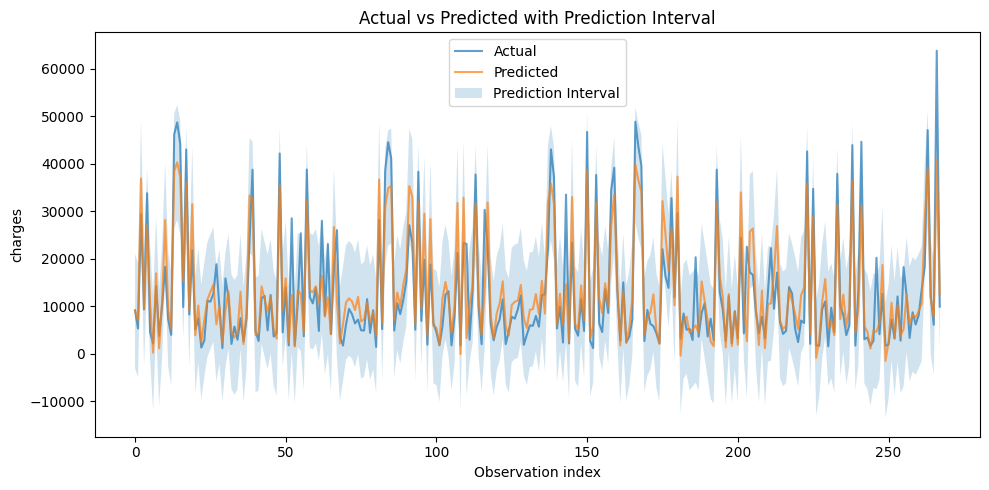

In [160]:
idx = np.arange(len(y_test))

plt.figure(figsize=(10, 5))

# Giá trị thực & dự báo
plt.plot(idx, y_test.values, label='Actual', alpha=0.7)
plt.plot(idx, compute_y_predict(X_train, X_test, y_train).values, label='Predicted', alpha=0.7)

# Khoảng tin cậy / dự báo
plt.fill_between(
    idx,
    compute_lower_bound(X_test, X_train, y_train, 268, 1070, 8).values,
    compute_upper_bound(X_test, X_train, y_train, 268, 1070, 8).values,
    alpha=0.2,
    label='Prediction Interval'
)

plt.xlabel('Observation index')
plt.ylabel('charges')
plt.title('Actual vs Predicted with Prediction Interval')
plt.legend()
plt.tight_layout()
plt.show()

# Kiểm tra các giả định về sai số của mô hình

In [161]:
display(Latex(r""" 
\begin{equation*}
    \psi \sim \mathcal{N}(0, \sigma^2)
\end{equation*}
              
\begin{equation*}
    \mathbb{E}(\psi) = 0, \text{Var}(\psi) = \sigma^2
\end{equation*}
"""))

<IPython.core.display.Latex object>

In [162]:
resid = y_test - compute_y_predict(X_train, X_test, y_train).values
resid

764       125.517976
887     -1796.571643
890     -7527.427762
1293     -152.784951
259      6777.118343
            ...     
109      7994.031168
575       461.399102
535     -1620.436882
543     22850.136498
846     -2445.885653
Name: charges, Length: 268, dtype: float64

In [163]:
mean_resid = resid.mean()

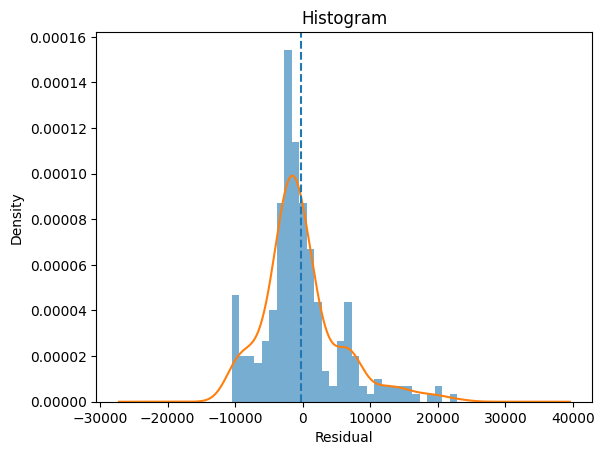

In [164]:
plt.figure()
resid.plot(kind='hist', bins=30, density=True, alpha=0.6)

resid.plot(kind='kde')
plt.axvline(mean_resid, linestyle = '--')

plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram")
plt.show()

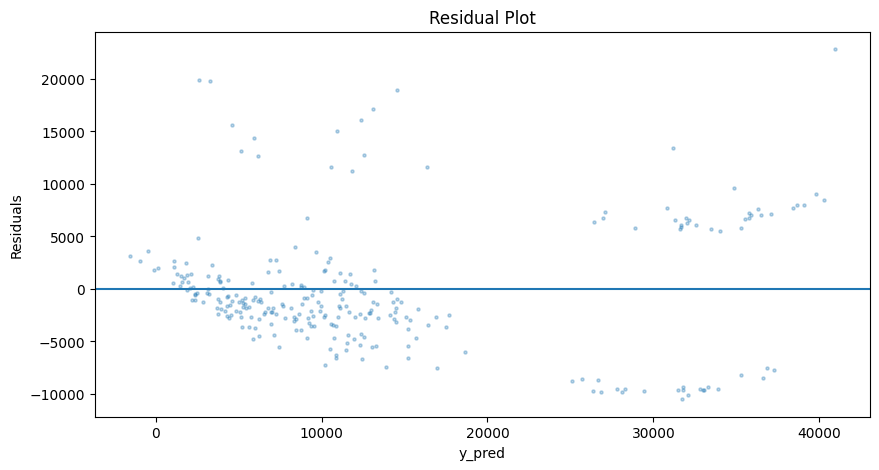

In [165]:
plt.figure(figsize=(10,5))
plt.scatter(compute_y_predict(X_train, X_test, y_train).values, resid, alpha=0.3, s=5)
plt.axhline(0)

plt.xlabel('y_pred')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# Dùng thư viện

In [166]:
df_cleaned

,age,bmi,children,charges,gender,is_smoker,region_southwest,region_northwest,region_northeast
0,19,27.900,0,16884.92400,0,1,1,0,0
1,18,33.770,1,1725.55230,1,0,0,0,0
2,28,33.000,3,4449.46200,1,0,0,0,0
3,33,22.705,0,21984.47061,1,0,0,1,0
4,32,28.880,0,3866.85520,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,0,1,0
1334,18,31.920,0,2205.98080,0,0,0,0,1
1335,18,36.850,0,1629.83350,0,0,0,0,0
1336,21,25.800,0,2007.94500,0,0,1,0,0


In [167]:
# chia dữ liệu thành 2 phần (train - test) với tỷ lệ 80 - 20
X = df_cleaned.drop(columns=['charges']) # ma trận X bỏ cột charges 
y = df_cleaned['charges']                # vector y chỉ có cột charges

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42     # để tái lập kết quả
)

In [168]:
X_train

,age,bmi,children,gender,is_smoker,region_southwest,region_northwest,region_northeast
560,46,19.950,2,0,0,0,1,0
1285,47,24.320,0,0,0,0,0,1
1142,52,24.860,0,0,0,0,0,0
969,39,34.320,5,0,0,0,0,0
486,54,21.470,3,0,0,0,1,0
...,...,...,...,...,...,...,...,...
1095,18,31.350,4,0,0,0,0,1
1130,39,23.870,5,0,0,0,0,0
1294,58,25.175,0,1,0,0,0,1
860,37,47.600,2,0,1,1,0,0


In [169]:
y_train

560      9193.83850
1285     8534.67180
1142    27117.99378
969      8596.82780
486     12475.35130
           ...     
1095     4561.18850
1130     8582.30230
1294    11931.12525
860     46113.51100
1126    10214.63600
Name: charges, Length: 1070, dtype: float64

In [170]:
X_test

,age,bmi,children,gender,is_smoker,region_southwest,region_northwest,region_northeast
764,45,25.175,2,0,0,0,0,1
887,36,30.020,0,0,0,0,1,0
890,64,26.885,0,0,1,0,1,0
1293,46,25.745,3,1,0,0,1,0
259,19,31.920,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...
109,63,35.090,0,1,1,0,0,0
575,58,27.170,0,0,0,0,1,0
535,38,28.025,1,1,0,0,0,1
543,54,47.410,0,0,1,0,0,0


In [171]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [172]:
import statsmodels.formula.api as smf

In [173]:
# nối ma trận X và vector y cho việc train thành 1 data frame
df2 = pd.concat([X_train, y_train], axis = 1)
df2

,age,bmi,children,gender,is_smoker,region_southwest,region_northwest,region_northeast,charges
560,46,19.950,2,0,0,0,1,0,9193.83850
1285,47,24.320,0,0,0,0,0,1,8534.67180
1142,52,24.860,0,0,0,0,0,0,27117.99378
969,39,34.320,5,0,0,0,0,0,8596.82780
486,54,21.470,3,0,0,0,1,0,12475.35130
...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,0,0,0,0,1,4561.18850
1130,39,23.870,5,0,0,0,0,0,8582.30230
1294,58,25.175,0,1,0,0,0,1,11931.12525
860,37,47.600,2,0,1,1,0,0,46113.51100


In [174]:
formula = 'Q("charges") ~ ' + ' + '.join(
    [f'Q("{col}")' for col in X_train])

In [175]:
model = smf.ols(formula, data=df2).fit()

In [176]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Q("charges")   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Tue, 20 Jan 2026   Prob (F-statistic):          1.32e-305
Time:                        02:24:14   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -1.259e+